In [15]:
# %pip install --upgrade ml_dtypes
import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import pandas as pd
import numpy as np

In [16]:
# Function to parse the TFRecord file
def parse_tfrecord(example_proto):
    feature_description = {
        "coordinates": tf.io.FixedLenFeature([2 * 21 * 3], tf.float32),  # Flattened 2x21x3 tensor
        "label": tf.io.FixedLenFeature([], tf.int64)
    }
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)
    coordinates = tf.reshape(parsed_features["coordinates"], (2, 21, 3))  # Reshape back to 2x21x3
    # label = parsed_features["label"]
    label = tf.one_hot(parsed_features["label"], depth=21)
    return coordinates, label

# Load the dataset from the TFRecord file
loaded_dataset = tf.data.TFRecordDataset("/home/andi/workspace/datasetsemogafinal.tfrecords")
loaded_dataset = loaded_dataset.map(parse_tfrecord)



In [17]:
dataset_list = list(loaded_dataset.take(20))

# Examine the first example
for x in range(-1,2,1):
    first_coordinates, first_label = dataset_list[x]
    print("First coordinates shape:", first_coordinates.shape)
    print("First label:", first_label.numpy())
    print("Sample coordinate values:")
    print(first_coordinates[:, 0:21, :].numpy())  # First instance, first 3 keypoints

First coordinates shape: (2, 21, 3)
First label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sample coordinate values:
[[[0.85337776 0.5246768  0.        ]
  [0.86728936 0.48885518 0.        ]
  [0.917256   0.46024138 0.        ]
  [0.961454   0.43893194 0.        ]
  [0.9868808  0.42121965 0.        ]
  [0.9870285  0.4818957  0.        ]
  [1.0714731  0.48025537 0.        ]
  [1.1146783  0.47748557 0.        ]
  [1.143367   0.4739256  0.        ]
  [0.9973537  0.50718975 0.        ]
  [1.0801795  0.50533694 0.        ]
  [1.1162574  0.50161684 0.        ]
  [1.138468   0.49906155 0.        ]
  [0.9991355  0.5303957  0.        ]
  [1.0788684  0.53025436 0.        ]
  [1.1147921  0.5248569  0.        ]
  [1.1382172  0.5210734  0.        ]
  [0.99749523 0.549999   0.        ]
  [1.0656524  0.55097586 0.        ]
  [1.0922751  0.5469065  0.        ]
  [1.1093081  0.54279244 0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.  

In [18]:
coordinates = []
labels = []
for x, y in loaded_dataset:
    coordinates.append(x.numpy())  # Append coordinates as NumPy arrays
    labels.append(y.numpy())  # Append labels as integers

In [19]:
split = 0.8
train_coordinates = np.array(coordinates[:int(len(coordinates)*split)])
train_labels = np.array(labels[:int(len(labels)*split)])

valid_coordinates = np.array(coordinates[int(len(coordinates)*split):])
valid_labels = np.array(labels[int(len(labels)*split):])

In [20]:
print(train_coordinates.shape)
print(train_labels.shape)
print(valid_coordinates.shape)

(24887, 2, 21, 3)
(24887, 21)
(6222, 2, 21, 3)


In [21]:
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Input(shape=(2, 21, 3)),
#     tf.keras.layers.Reshape((21, 3, 2)),
#     tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 1)),
#     tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 1)),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.4),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dense(21, activation='softmax')
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()

In [22]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(2, 21, 3)),
    tf.keras.layers.Reshape((21, 3, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 1)),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 1)),
    tf.keras.layers.Reshape((5, 3 * 128)),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(21, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 21, 3, 2)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 3, 64)      │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 21, 3, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 5, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,061 (2.19 MB)

 Trainable params: 572,885 (2.19 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [23]:
# from tensorflow.keras.applications import EfficientNetB1

# inputs = tf.keras.Input(shape=(2, 21, 3))
# x = tf.keras.layers.Flatten()(inputs)
# x = tf.keras.layers.Dense(32*32, activation='relu')(x)
# x = tf.keras.layers.Reshape((32, 32, 1))(x)
# x = tf.keras.layers.Lambda(
#     lambda x: tf.repeat(x, 3, axis=-1),
#     output_shape=(32, 32, 3)
# )(x)
# base_model = EfficientNetB1(weights="imagenet", include_top=False, input_shape=(32, 32, 3), classifier_activation="relu")
# base_model.trainable = False  # Freeze all layers in base_model
# x = base_model(x)
# x = tf.keras.layers.GlobalAveragePooling2D()(x)
# outputs = tf.keras.layers.Dense(21, activation="softmax")(x) 

# model = tf.keras.Model(inputs, outputs)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()

In [24]:
# Count total samples


total_count = sum(1 for _ in loaded_dataset)
train_size = int(0.8 * total_count)

# Shuffle before splitting
shuffled_dataset = loaded_dataset.shuffle(buffer_size=total_count, seed=64)

# Use enumerate and filter to split
train_ds = shuffled_dataset.enumerate().filter(lambda i, _: i < train_size).map(lambda i, data: data).batch(32)
valid_ds = shuffled_dataset.enumerate().filter(lambda i, _: i >= train_size).map(lambda i, data: data).batch(32)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20
)

Epoch 1/20
    778/Unknown 15s 13ms/step - accuracy: 0.1575 - loss: 2.9702

2025-06-30 22:26:22.638176: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10119376914533931647
2025-06-30 22:26:22.638231: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 5946414037406147364
2025-06-30 22:26:22.638247: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13334466892040367540
/home/andi/miniconda3/envs/wtf/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


778/778 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.1576 - loss: 2.9698 - val_accuracy: 0.5400 - val_loss: 1.6729
Epoch 2/20


2025-06-30 22:26:25.207136: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15852146651915227590
2025-06-30 22:26:25.207175: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9649146555510350981
2025-06-30 22:26:25.207192: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 17314406263337664145


778/778 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4409 - loss: 1.7973

...

2025-06-30 22:30:26.240972: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9649146555510350981
2025-06-30 22:30:26.241013: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 17314406263337664145
2025-06-30 22:30:26.241027: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15852146651915227590


778/778 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9815 - loss: 0.0669

2025-06-30 22:30:37.156809: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10119376914533931647


778/778 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9815 - loss: 0.0669 - val_accuracy: 0.9886 - val_loss: 0.0394


2025-06-30 22:30:39.323825: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9649146555510350981
2025-06-30 22:30:39.323864: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 15852146651915227590


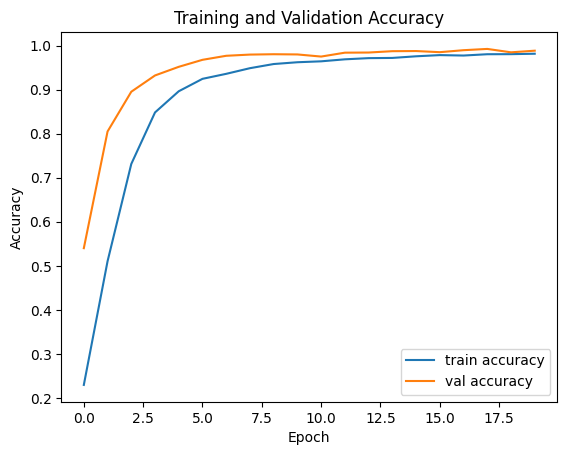

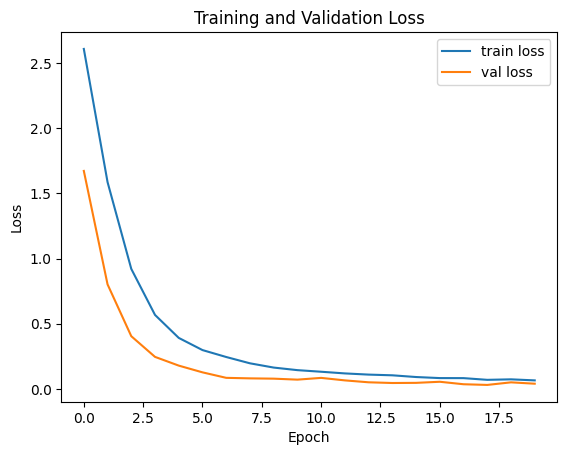

In [25]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━

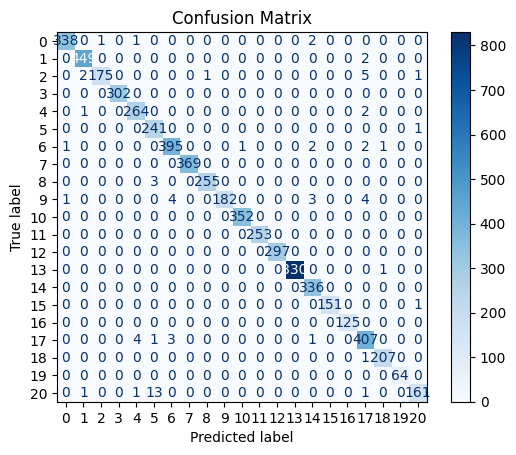

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get all validation data
y_true = []
y_pred = []

for batch in valid_ds:
    X_batch, y_batch = batch
    preds = model.predict(X_batch)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [30]:
model.save("datasetsemogafinal.h5")


In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_model_path = 'datasetsemogafinalmakeLSTM.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmp0akqf5l_/assets


INFO:tensorflow:Assets written to: /tmp/tmp0akqf5l_/assets


Saved artifact at '/tmp/tmp0akqf5l_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2, 21, 3), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 21), dtype=tf.float32, name=None)
Captures:
  127688593272720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593275408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593275792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593276368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593276560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593275984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593276752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593275024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593275600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127688593276176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1276885932746

W0000 00:00:1751297881.631642 1278611 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1751297881.631658 1278611 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2025-06-30 22:38:01.631826: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0akqf5l_
2025-06-30 22:38:01.634395: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-06-30 22:38:01.634441: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp0akqf5l_
2025-06-30 22:38:01.667446: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-06-30 22:38:01.809332: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp0akqf5l_
2025-06-30 22:38:01.858234: I tensorflow/cc/saved_model/loader.cc:462] SavedModel load for tags { serve }; Status: success: OK. Took 226409 microseconds.
loc(callsite(callsite(fused["CudnnRNNV3:", "

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["CudnnRNNV3:", "sequential_1_1/lstm_1_1/CudnnRNNV3@__inference_function_530819"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_530970"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["CudnnRNNV3:", "sequential_1_1/lstm_1_1/CudnnRNNV3@__inference_function_530819"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_530970"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): Error code: ERROR_NEEDS_CUSTOM_OPS
<unknown>:0: error: failed while converting: 'main': 
Some ops in the model are custom ops, See instructions to implement custom ops: https://www.tensorflo